# Applications of Artificial Intelligence in Cyber Security

## Lab 7: PCA and MLP based Ransomeware Classification

# Dataset: Ransomware

Dataset Link: https://github.com/rissgrouphub/ransomwaredataset2016.git

## Download and Setup Dataset (Colab Users Only)

In [1]:
!rm -rf "/content/ransomwaredataset2016"
!git clone "https://github.com/rissgrouphub/ransomwaredataset2016.git"
!unzip "/content/ransomwaredataset2016/RansomwareData.zip" -d "/content/ransomwaredataset2016"

Cloning into 'ransomwaredataset2016'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 7 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), 1.03 MiB | 3.75 MiB/s, done.
Archive:  /content/ransomwaredataset2016/RansomwareData.zip
  inflating: /content/ransomwaredataset2016/RansomwareData.csv  


## Imports and Load Dataset (For All Users)

In [2]:
# imports for data handling
# The os module allows to interact with the operating system for example reading and writing from directories
import os
# Powerful library for performing Different FUnctions on Arrays.
import numpy as np
# Pandas is used for data manipulation, analysis specially in tables of time series data.
import pandas as pd
# Seaborn is a python data visualization library based on matplotlib. it provides a high-level interface for drawing attractive and informative statistitcal graphics.
import seaborn as sns
# matplotlib is a comprehensive library plotting for creating static, animated, and interactive visualizatinos in Python.
import matplotlib.pyplot as plt
# This module implements specialized container datatypes providing alternatives to Python's general purpose built in containers, dict, list, set and tuple.
from collections import Counter

# imports for preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# imports for model evaluation
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

# imports for MLPClassifier
from sklearn.neural_network import MLPClassifier

In [3]:
dataset_path = '/content/ransomwaredataset2016'
filename = 'RansomwareData.csv'
filepath = os.path.join(dataset_path, filename)


Read column names from file `VariableNames.txt`

In [4]:
variable_names = open(os.path.join(dataset_path, 'VariableNames.txt'),encoding='utf-8').readlines()
columns = []
for idx, variable_name in enumerate(variable_names):
    variable_name = variable_name.split(';')
    columns.append(variable_name[1].strip())
columns = np.array(columns)
columns[1] = 'Label'
print(columns.shape)


(30970,)


Read Ransomware Family Names (for Multiclass classification) from file `Family Names ID.txt`

In [5]:
family_names_file = open(os.path.join(dataset_path, 'Family Names ID.txt')).readlines()[2:]
family_names = {}
for idx, row in enumerate(family_names_file):
    row = row.strip()
    if len(row) <= 0: continue
    family_name, id = row[:-3].strip(), row[-3:].strip()
    if family_name != 'Goodware':
        family_name = family_name[1:-1]
    family_names[int(id)] = family_name
family_names


{0: 'Goodware',
 1: 'Critroni',
 2: 'CryptLocker',
 3: 'CryptoWall',
 4: 'KOLLAH',
 5: 'Kovter',
 6: 'Locker',
 7: 'MATSNU',
 8: 'PGPCODER',
 9: 'Reveton',
 10: 'TeslaCrypt',
 11: 'Trojan-Ransom'}

Load dataset as dataframe and apply some preprocessing

In [6]:
# read dataset
df = pd.read_csv(filepath, header=None)
df.columns = columns
# replace Null values with 0
df.fillna(0, inplace=True)
# shuffle rows for better train/val/test division
sampler = np.random.permutation(len(df))
df = df.take(sampler)
df = df.reset_index(drop=True)
# drop these columns due to their insignificance
df = df.drop(['ID'], axis=1)
columns = df.columns
# show dataframe
df


,Label,Ransomware Family,API:GetSystemDirectoryA,API:WriteConsoleA,API:NtOpenFile,API:NtCreateProcessEx,API:GetSystemInfo,API:WriteConsoleW,API:NtReadVirtualMemory,API:RemoveDirectoryA,...,STR:16258,STR:16259,STR:16260,STR:16261,STR:16262,STR:16263,STR:16264,STR:16265,STR:16266,STR:16267
0,0,0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2,1,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,7,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1519,0,0,1,1,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1520,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1521,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1522,0,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0


Remove columns containing only one value

In [7]:
# df.apply function takes column one-by-one and return count of unique values
unique_vals_count_per_col = df.apply(lambda x: len(pd.unique(x)))
# Counter will count frequency of unique values, indicating number of columns with that unique value
print(Counter(unique_vals_count_per_col.values))
# those columns are relevant having more than one unique value
relevant_columns = unique_vals_count_per_col > 1
# select only relevant columns to remove irrelevant columns
df2 = df.iloc[:, relevant_columns.values]
columns = df.columns
# show dataframe
df2


Counter({np.int64(2): 23617, np.int64(1): 7351, np.int64(12): 1})


,Label,Ransomware Family,API:GetSystemDirectoryA,API:WriteConsoleA,API:NtOpenFile,API:NtCreateProcessEx,API:GetSystemInfo,API:WriteConsoleW,API:NtReadVirtualMemory,API:RemoveDirectoryA,...,STR:16247,STR:16252,STR:16253,STR:16255,STR:16256,STR:16259,STR:16260,STR:16261,STR:16264,STR:16267
0,0,0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2,1,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,7,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1519,0,0,1,1,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1520,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1521,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1522,0,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
# separate dataframe into X and y
X = df2.drop(['Label', 'Ransomware Family'], axis=1)
y_binary = df2['Label']
y_multi = df2['Ransomware Family']


In [9]:
# check frequency of each binary class
class_labels_binary = df2['Label'].unique()
print(df2['Label'].value_counts())


Label
0    942
1    582
Name: count, dtype: int64


In [10]:
# check frequency of each multi class
class_labels_multi = df2['Ransomware Family'].unique()
print(df2['Ransomware Family'].value_counts())


Ransomware Family
0     942
2     107
6      97
9      90
5      64
7      59
1      50
3      46
11     34
4      25
10      6
8       4
Name: count, dtype: int64


## Evaluation Function

In [11]:
def get_one_vs_all(confusion_matrix, label):
    tp = confusion_matrix[label, label]
    fn = np.sum(confusion_matrix[label, :]) - tp
    fp = np.sum(confusion_matrix[:, label]) - tp
    tn = np.sum(confusion_matrix) - tp - fn - fp
    return tp, fn, fp, tn

def calculate_metrics(y_true, y_pred, y_prob, class_labels):
    labels = np.unique(y_true)
    columns = ['class_label', 'accuracy', 'recall', 'precision', 'f1_score', 'area_under_roc', 'area_under_pr']
    df_metrics = pd.DataFrame(index=range(len(labels)))
    cm = metrics.confusion_matrix(y_true, y_pred)

    for idx, label in enumerate(labels):
        y_true2 = y_true.copy()
        y_pred2 = y_pred.copy()
        y_prob2 = y_prob[:, label]
        # print('[condition]', np.where(y_true == label))
        y_true2[y_true == label] = 1
        y_true2[y_true != label] = 0
        y_pred2[y_pred == label] = 1
        y_pred2[y_pred != label] = 0
        tp, fn, fp, tn = get_one_vs_all(cm, idx)
        # print(tp, fn, fp, tn)
        accuracy = (tp + tn) / (tp + tn + fn + fp)
        epsilon = 1e-7 # is used so that to avoid divide by zero error
        recall = tp / (tp + fn + epsilon)
        precision = tp / (tp + fp + epsilon)
        f1_score = 2 * recall * precision / (recall + precision)
        area_under_roc = metrics.roc_auc_score(y_true2, y_prob2)

        precisions, recalls, _ = metrics.precision_recall_curve(y_true2, y_prob2)
        area_under_pr = metrics.auc(recalls, precisions)

        # print('[label]', label)
        df_metrics.loc[label, 'class_label'] = class_labels[label]
        df_metrics.loc[label, 'accuracy'] = accuracy
        df_metrics.loc[label, 'precision'] = precision
        df_metrics.loc[label, 'recall'] = recall
        df_metrics.loc[label, 'f1_score'] = f1_score
        df_metrics.loc[label, 'area_under_roc'] = area_under_roc
        df_metrics.loc[label, 'area_under_pr'] = area_under_pr

    if len(labels) == 2:
        df_metrics = df_metrics.drop(index=0)

    print(df_metrics)
    # df_metrics['class_label'] = df_metrics['class_label'].astype(int)

    return df_metrics


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.metrics import classification_report

def get_one_vs_all(confusion_matrix, label):
    tp = confusion_matrix[label, label]
    fn = np.sum(confusion_matrix[label, :]) - tp
    fp = np.sum(confusion_matrix[:, label]) - tp
    tn = np.sum(confusion_matrix) - tp - fn - fp
    return tp, fn, fp, tn

def calculate_metrics(y_true, y_pred, y_prob, class_labels):
    labels = np.unique(y_true)
    columns = ['class_label', 'accuracy', 'recall', 'precision', 'f1_score', 'area_under_roc', 'area_under_pr']
    df_metrics = pd.DataFrame(index=range(len(labels)))
    cm = metrics.confusion_matrix(y_true, y_pred)

    for idx, label in enumerate(labels):
        y_true2 = y_true.copy()
        y_pred2 = y_pred.copy()
        y_prob2 = y_prob[:, label]
        # print('[condition]', np.where(y_true == label))
        y_true2[y_true == label] = 1
        y_true2[y_true != label] = 0
        y_pred2[y_pred == label] = 1
        y_pred2[y_pred != label] = 0
        tp, fn, fp, tn = get_one_vs_all(cm, idx)
        # print('[tp, fn, fp, tn]', tp, fn, fp, tn)
        accuracy = (tp + tn) / (tp + tn + fn + fp)
        epsilon = 1e-7 # is used so that to avoid divide by zero error
        recall = tp / (tp + fn + epsilon)
        precision = tp / (tp + fp + epsilon)
        f1_score = 2 * recall * precision / (recall + precision)
        area_under_roc = metrics.roc_auc_score(y_true2, y_prob2)

        precisions, recalls, _ = metrics.precision_recall_curve(y_true2, y_prob2)
        area_under_pr = metrics.auc(recalls, precisions)

        # print('[label]', label)
        df_metrics.loc[label, 'class_label'] = class_labels[label]
        df_metrics.loc[label, 'accuracy'] = accuracy
        df_metrics.loc[label, 'precision'] = precision
        df_metrics.loc[label, 'recall'] = recall
        df_metrics.loc[label, 'f1_score'] = f1_score
        df_metrics.loc[label, 'area_under_roc'] = area_under_roc
        df_metrics.loc[label, 'area_under_pr'] = area_under_pr

    if len(labels) == 2:
        df_metrics = df_metrics.drop(index=0)

    print(df_metrics)
    # df_metrics['class_label'] = df_metrics['class_label'].astype(int)

    return df_metrics

def plot_roc_curve_multi(y_true, y_prob, class_labels, suptitle):
    fig = plt.figure(figsize=(8, 6))
    fig.suptitle(suptitle)

    labels = np.unique(y_true)
    roc_curves = {}

    # plot roc curves in one-vs-all manner, meaning one curve per class
    for label in labels:
        y_true2 = y_true.copy()
        y_true2[y_true == label] = 1
        y_true2[y_true != label] = 0
        y_prob2 = y_prob[:, label]
        FP_rate, TP_rate, _ = metrics.roc_curve(y_true2, y_prob2)
        roc_auc = metrics.roc_auc_score(y_true2, y_prob2)
        plt.plot(FP_rate, TP_rate, label=f'{class_labels[label]} (roc_auc = {roc_auc:.4f})')

    plt.xlabel('FP Rate')
    plt.ylabel('TP Rate')
    plt.legend(fontsize=8)

def plot_roc_curve_binary(y_true, y_prob, suptitle):
    fig = plt.figure(figsize=(8, 6))
    fig.suptitle(suptitle)
    FP_rate, TP_rate, _ = metrics.roc_curve(y_true, y_prob[:, 1])
    roc_auc = metrics.roc_auc_score(y_true, y_prob[:, 1])
    plt.plot(FP_rate, TP_rate, label=f'Ransomware (roc_auc = {roc_auc:.4f})')
    plt.xlabel('FP Rate')
    plt.ylabel('TP Rate')
    plt.legend(fontsize=8)

def plot_pr_curve_binary(y_true, y_prob, suptitle):
    fig = plt.figure(figsize=(8, 6))
    fig.suptitle(suptitle)
    precisions, recalls, _ = metrics.precision_recall_curve(y_true, y_prob[:, 1])
    area_under_pr = metrics.auc(recalls, precisions)
    plt.plot(recalls, precisions, label=f'Ransomware (PR_AUC = {area_under_pr:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.show()

def plot_pr_curve_multi(y_true, y_prob, class_labels, suptitle):
    fig = plt.figure(figsize=(10, 8))
    fig.suptitle(suptitle)

    labels = np.unique(y_true)

    for label in labels:
        y_true2 = y_true.copy()
        y_true2[y_true == label] = 1
        y_true2[y_true != label] = 0
        y_prob2 = y_prob[:, label]
        precisions, recalls, _ = metrics.precision_recall_curve(y_true2, y_prob2)
        area_under_pr = metrics.auc(recalls, precisions)
        plt.plot(recalls, precisions, label=f'{class_labels[label]} (PR_AUC = {area_under_pr:.4f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.show()

def print_metrices(y_true, y_pred):
    print(f'Accuracy: {metrics.accuracy_score(y_true, y_pred):.4f}')

    # Check if this is a binary classification context
    if len(np.unique(y_true)) == 2:
        # For binary classification, recall/precision/f1 for the positive class (1)
        print(f'Recall: {metrics.recall_score(y_true, y_pred, pos_label=1):.4f}')
        print(f'Precision: {metrics.precision_score(y_true, y_pred, pos_label=1):.4f}')
        print(f'F1-Score: {metrics.f1_score(y_true, y_pred, pos_label=1):.4f}')
    else:
        # For multi-class, use weighted average for a summary
        print(f'Recall: {metrics.recall_score(y_true, y_pred, average="weighted"):.4f}')
        print(f'Precision: {metrics.precision_score(y_true, y_pred, average="weighted"):.4f}')
        print(f'F1-Score: {metrics.f1_score(y_true, y_pred, average="weighted"):.4f}')

    # Try to get y_prob from global scope for AUC metrics
    global y_prob
    if 'y_prob' in globals() and y_prob is not None:
        if y_prob.shape[1] == 2: # Binary classification with probabilities for two classes
            try:
                print(f'Area Under ROC Curve: {metrics.roc_auc_score(y_true, y_prob[:, 1]):.4f}')
                precisions, recalls, _ = metrics.precision_recall_curve(y_true, y_prob[:, 1])
                print(f'Area Under PR Curve: {metrics.auc(recalls, precisions):.4f}')
            except Exception as e:
                print(f"Could not calculate AUC metrics for binary classification: {e}")
        else:
            print("AUC metrics for multi-class are not directly implemented in print_metrices with current y_prob format.")
    else:
        print("y_prob not available in global scope for AUC calculations.")

    print("\nPrecison, Recall, F1-Score:")
    print(classification_report(y_true, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


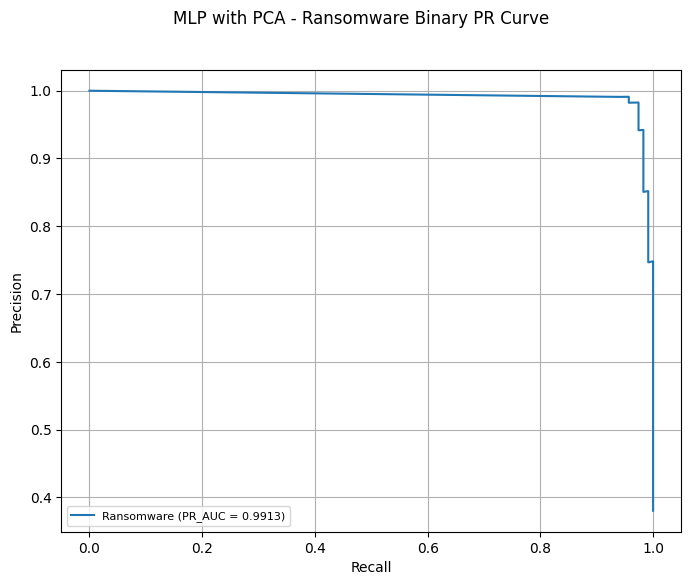

In [19]:
from sklearn.decomposition import PCA

y = y_binary
class_names_binary = ['Goodware', 'Malware']

# Re-dividing data into training, testing and validation for binary classification
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X, y, test_size=0.20, random_state=103, stratify=y)
X_train_bin, X_val_bin, y_train_bin, y_val_bin = train_test_split(X_train_bin, y_train_bin, test_size=0.20, random_state=103, stratify=y_train_bin)

# Re-applying PCA for binary classification
n_components_bin = 100
pca_bin = PCA(n_components=n_components_bin)
pca_bin.fit(X_train_bin)
X_train_pca_bin = pca_bin.transform(X_train_bin)
X_test_pca_bin = pca_bin.transform(X_test_bin)

# Re-training MLP for binary classification with PCA
mlp_bin = MLPClassifier(hidden_layer_sizes=(128, 128, 128, len(class_names_binary)), max_iter=200, random_state=105, verbose=False)
mlp_bin.fit(X_train_pca_bin, y_train_bin)
mlp_pca_y_prob_binary = mlp_bin.predict_proba(X_test_pca_bin)

plot_pr_curve_binary(y_test_bin, mlp_pca_y_prob_binary, suptitle='MLP with PCA - Ransomware Binary PR Curve')

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


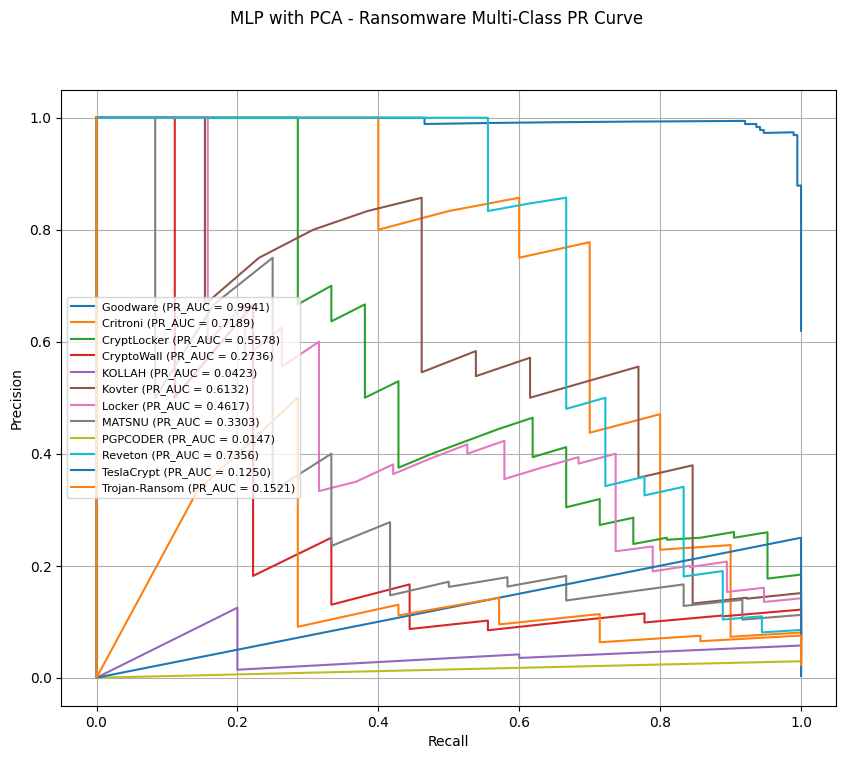

In [20]:
# Re-defining y and class_names for multi-class context
y = y_multi
class_names = list(family_names.values())

# Re-dividing data into training, testing and validation for multi-class classification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=103, stratify=y)

# Re-applying PCA for multi-class classification (using n_components=100 as in cell mBAPoyRu5AUq)
n_components_multi = 100
pca_multi = PCA(n_components=n_components_multi)
pca_multi.fit(X_train)
X_test_pca_multi = pca_multi.transform(X_test)

# Re-training MLP for multi-class classification with PCA
mlp_multi = MLPClassifier(hidden_layer_sizes=(128, 128, 128, len(class_names)), max_iter=100, random_state=105, verbose=False)
mlp_multi.fit(pca_multi.transform(X_train), y_train)
y_prob_multi = mlp_multi.predict_proba(X_test_pca_multi)

plot_pr_curve_multi(y_test, y_prob_multi, class_names, suptitle='MLP with PCA - Ransomware Multi-Class PR Curve')

## Binary Class

### Preprocessing

In [21]:
y = y_binary
class_labels = sorted(class_labels_binary)
class_names = ['Goodware', 'Malware']
print(class_labels)


[np.int64(0), np.int64(1)]


In [22]:
# Dividing data into training, testing and validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=103, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=103, stratify=y_train)
print(X.shape, y.shape)
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)


(1524, 23616) (1524,)
(975, 23616) (975,)
(244, 23616) (244,)
(305, 23616) (305,)


### PCA Visialization

In [23]:
from sklearn.decomposition import PCA
pca = PCA(n_components=5)
pca.fit(X_train)
print('PCA fit completed')
# print(pca.explained_variance_ratio_)
# print(pca.singular_values_)

PCA fit completed


Draw Scree Plot to show the importance of principle components

<BarContainer object of 5 artists>

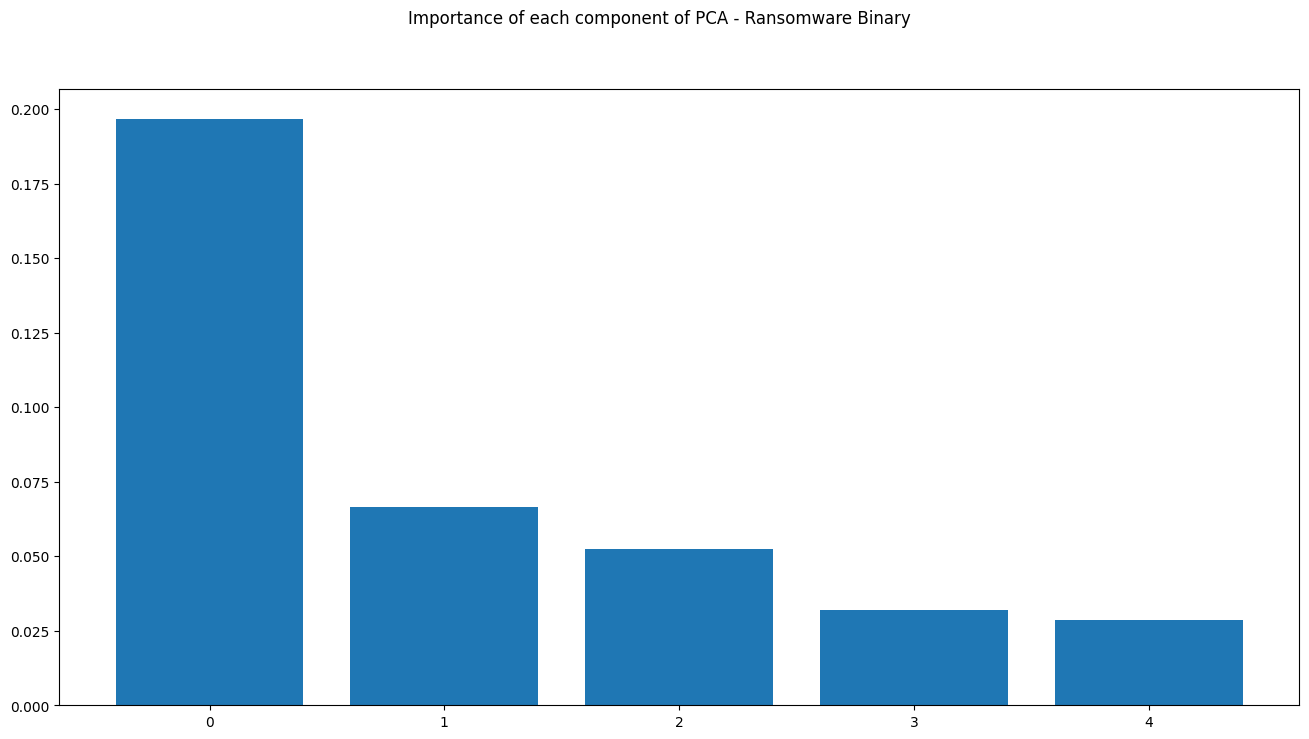

In [24]:
plt.figure(figsize=(16, 8))
plt.suptitle('Importance of each component of PCA - Ransomware Binary')
plt.bar(range(len(pca.explained_variance_ratio_)), pca.explained_variance_ratio_)

X.shape: (1524, 23616) ; X_train_pca.shape: (975, 5)


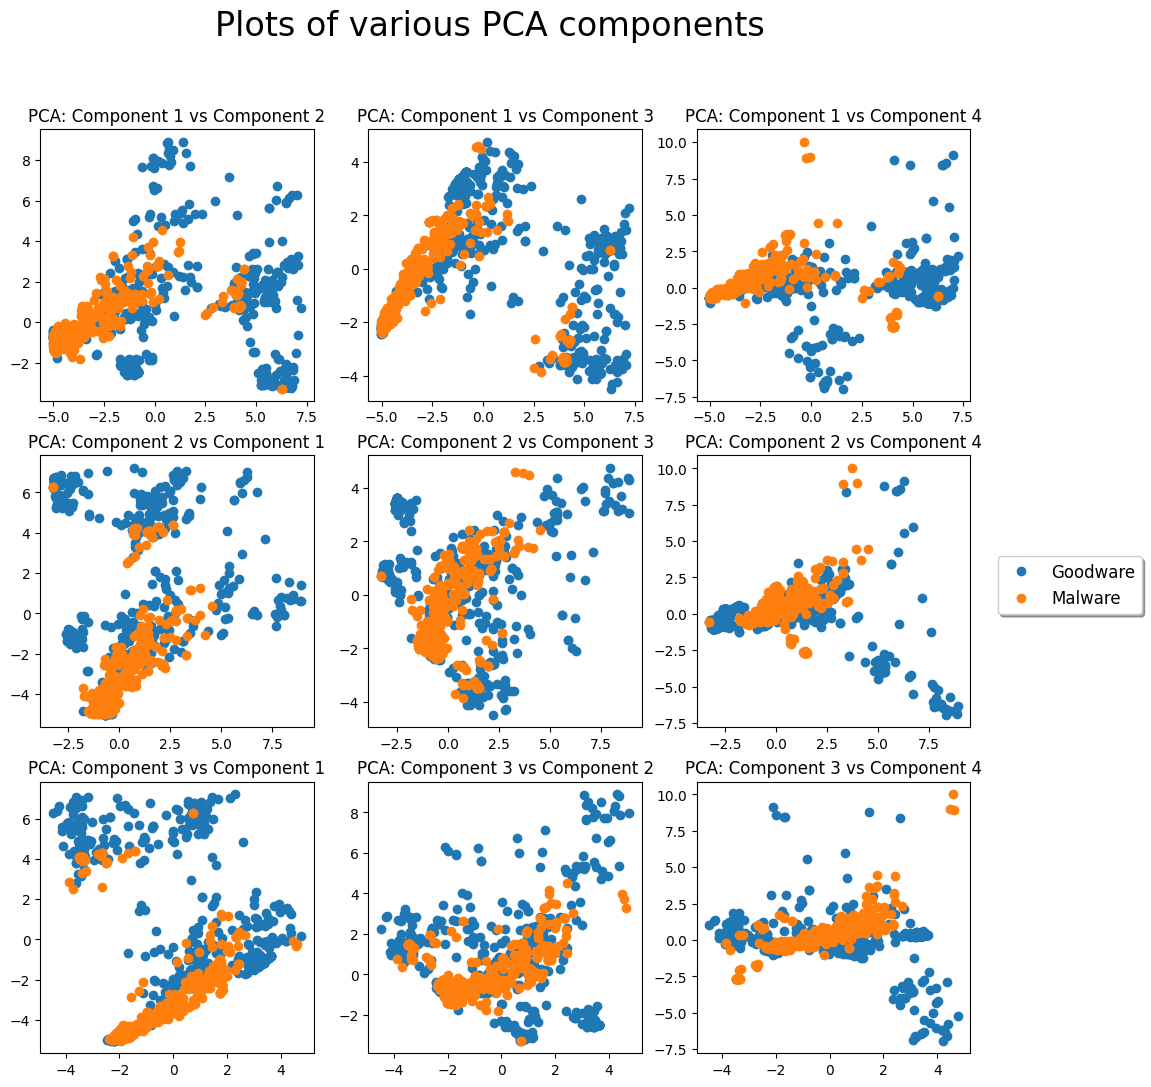

In [25]:
X_train_pca = pca.transform(X_train)
print('X.shape:', X.shape, '; X_train_pca.shape:', X_train_pca.shape)
fig, axes = plt.subplots(3, 3)
fig.set_size_inches(12, 12)
fig.suptitle('Plots of various PCA components', fontsize=24)

for class_idx in class_labels:
    indices = (y_train == class_idx)
    i2 = 0
    for i in range(3):
        j2 = 0
        for j in range(4):
            if i == j: continue
            x_coords = X_train_pca[indices, i]
            y_coords = X_train_pca[indices, j]
            label = class_names[class_idx]
            axes[i2, j2].plot(x_coords, y_coords, 'o', label=label)
            subplot_title = f'PCA: Component {i + 1} vs Component {j + 1}'
            axes[i2, j2].set_title(subplot_title)
            j2 += 1
        i2 += 1

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(handles=handles, labels=labels, loc='center right', fancybox=True, shadow=True, fontsize=12, bbox_to_anchor=(1.05, 0.5))


### MLP without PCA

In [26]:
mlp = MLPClassifier(hidden_layer_sizes=(128, 128, 128, len(class_names)), max_iter=10, random_state=105, verbose=True)
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)
y_prob = mlp.predict_proba(X_test)
mlp_metrics_binary = calculate_metrics(y_test, y_pred, y_prob, class_names)
mlp_metrics_binary['label-type'] = 'binary'
mlp_metrics_binary['model'] = 'MLP-without-PCA'
mlp_metrics_binary

Iteration 1, loss = 0.56912480
Iteration 2, loss = 0.35738658
Iteration 3, loss = 0.30029687
Iteration 4, loss = 0.27511508
Iteration 5, loss = 0.25569864
Iteration 6, loss = 0.24059396
Iteration 7, loss = 0.22834820
Iteration 8, loss = 0.22259235
Iteration 9, loss = 0.21945648
Iteration 10, loss = 0.21565439


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


  class_label  accuracy  precision    recall  f1_score  area_under_roc  \
1     Malware  0.967213   0.990741  0.922414  0.955357        0.994184   

   area_under_pr  
1       0.990749  


,class_label,accuracy,precision,recall,f1_score,area_under_roc,area_under_pr,label-type,model
1,Malware,0.967213,0.990741,0.922414,0.955357,0.994184,0.990749,binary,MLP-without-PCA


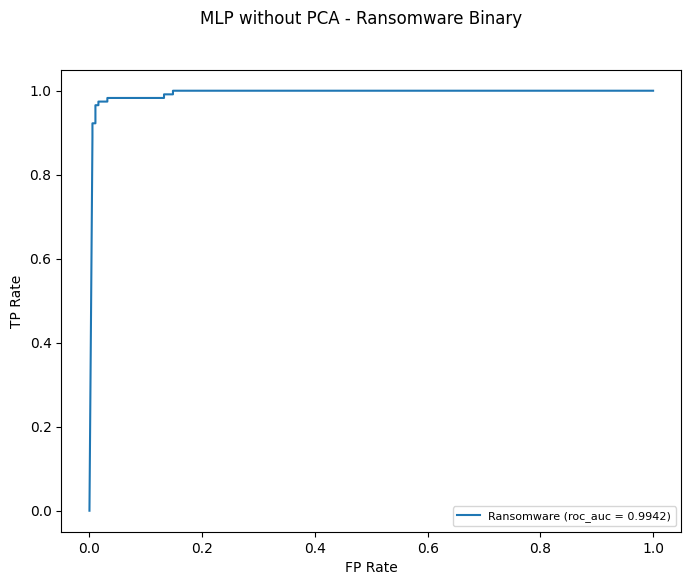

In [27]:
y_prob = mlp.predict_proba(X_test)
plot_roc_curve_binary(y_test, y_prob, suptitle='MLP without PCA - Ransomware Binary')

In [28]:
print_metrices(y_test, y_pred)

Accuracy: 0.9672
Recall: 0.9224
Precision: 0.9907
F1-Score: 0.9554
Area Under ROC Curve: 0.9942
Area Under PR Curve: 0.9907

Precison, Recall, F1-Score:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       189
           1       0.99      0.92      0.96       116

    accuracy                           0.97       305
   macro avg       0.97      0.96      0.96       305
weighted avg       0.97      0.97      0.97       305



### MLP with PCA

In [29]:
n_components = 100
pca = PCA(n_components=n_components)
pca.fit(X_train)
print(f'Variance explained by first {n_components} components:', sum(pca.explained_variance_ratio_))

# transform train dataset using PCA
X_train_pca = pca.transform(X_train)
print('X_train.shape:', X_train.shape, '; X_train_pca.shape:', X_train_pca.shape)
# transform val dataset using PCA
X_val_pca = pca.transform(X_val)
print('X_val.shape:', X_val.shape, '; X_val_pca.shape:', X_val_pca.shape)
# transform test dataset using PCA
X_test_pca = pca.transform(X_test)
print('X_test.shape:', X_test.shape, '; X_test_pca.shape:', X_test_pca.shape)


Variance explained by first 100 components: 0.8299179673172263
X_train.shape: (975, 23616) ; X_train_pca.shape: (975, 100)
X_val.shape: (244, 23616) ; X_val_pca.shape: (244, 100)
X_test.shape: (305, 23616) ; X_test_pca.shape: (305, 100)


In [46]:
mlp = MLPClassifier(hidden_layer_sizes=(128, 64, 100, len(class_names)), max_iter=25, random_state=105, verbose=True)
mlp.fit(X_train_pca, y_train)
y_pred = mlp.predict(X_test_pca)
y_prob = mlp.predict_proba(X_test_pca)
mlp_pca_metrics_binary = calculate_metrics(y_test, y_pred, y_prob, class_names)
mlp_pca_metrics_binary['label-type'] = 'binary'
mlp_pca_metrics_binary['model'] = 'MLP-with-PCA'
mlp_pca_metrics_binary

Iteration 1, loss = 2.07948728
Iteration 2, loss = 1.71947838
Iteration 3, loss = 1.45760781
Iteration 4, loss = 1.29762878
Iteration 5, loss = 1.16547356
Iteration 6, loss = 1.06369926
Iteration 7, loss = 0.97888685
Iteration 8, loss = 0.90321533
Iteration 9, loss = 0.83663454
Iteration 10, loss = 0.78196892
Iteration 11, loss = 0.73250781
Iteration 12, loss = 0.68977930
Iteration 13, loss = 0.65037977
Iteration 14, loss = 0.61596423
Iteration 15, loss = 0.58456691
Iteration 16, loss = 0.55534396
Iteration 17, loss = 0.52917825
Iteration 18, loss = 0.50313393
Iteration 19, loss = 0.48390714
Iteration 20, loss = 0.46113390
Iteration 21, loss = 0.44005395
Iteration 22, loss = 0.42256113
Iteration 23, loss = 0.40422577
Iteration 24, loss = 0.38948394
Iteration 25, loss = 0.37472627
      class_label  accuracy  precision    recall  f1_score  area_under_roc  \
0        Goodware  0.963934   0.949495  0.994709  0.971576        0.997035   
1        Critroni  0.986885   0.875000  0.700000  0.7

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(
/tmp/ipython-input-575389311.py:35: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * recall * precision / (recall + precision)
/tmp/ipython-input-575389311.py:35: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * recall * precision / (recall + precision)
/tmp/ipython-input-575389311.py:35: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * recall * precision / (recall + precision)
/tmp/ipython-input-575389311.py:35: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * recall * precision / (recall + precision)


,class_label,accuracy,precision,recall,f1_score,area_under_roc,area_under_pr,label-type,model
0,Goodware,0.963934,0.949495,0.994709,0.971576,0.997035,0.998034,binary,MLP-with-PCA
1,Critroni,0.986885,0.875000,0.700000,0.777778,0.938475,0.758957,binary,MLP-with-PCA
2,CryptLocker,0.901639,0.371429,0.619048,0.464286,0.948105,0.656505,binary,MLP-with-PCA
3,CryptoWall,0.960656,0.285714,0.222222,0.250000,0.950826,0.405857,binary,MLP-with-PCA
4,KOLLAH,0.983607,0.000000,0.000000,NaN,0.961333,0.300661,binary,MLP-with-PCA
5,Kovter,0.977049,0.800000,0.615385,0.695652,0.972603,0.744429,binary,MLP-with-PCA
6,Locker,0.927869,0.444444,0.631579,0.521739,0.943044,0.621675,binary,MLP-with-PCA
7,MATSNU,0.967213,0.625000,0.416667,0.500000,0.959898,0.575648,binary,MLP-with-PCA
8,PGPCODER,0.996721,0.000000,0.000000,NaN,0.858553,0.011364,binary,MLP-with-PCA
9,Reveton,0.973770,0.916667,0.611111,0.733333,0.943089,0.819644,binary,MLP-with-PCA


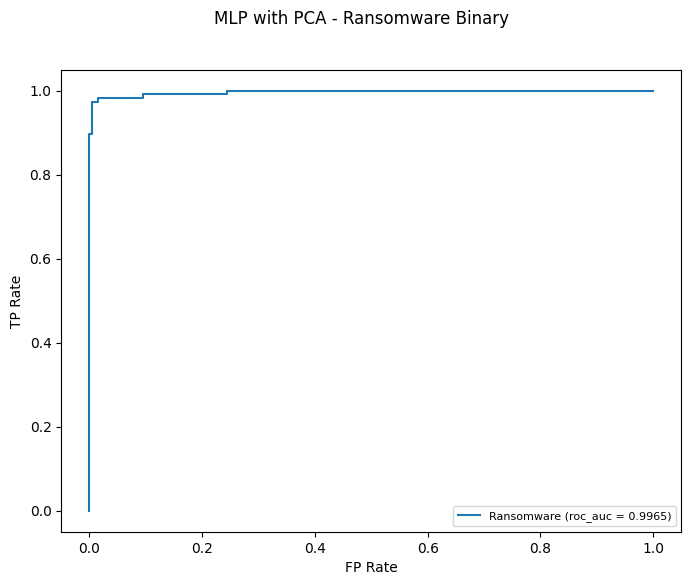

In [31]:
y_prob = mlp.predict_proba(X_test_pca)
plot_roc_curve_binary(y_test, y_prob, suptitle='MLP with PCA - Ransomware Binary')

In [32]:
print_metrices(y_test, y_pred)

Accuracy: 0.9803
Recall: 0.9569
Precision: 0.9911
F1-Score: 0.9737
Area Under ROC Curve: 0.9965
Area Under PR Curve: 0.9954

Precison, Recall, F1-Score:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       189
           1       0.99      0.96      0.97       116

    accuracy                           0.98       305
   macro avg       0.98      0.98      0.98       305
weighted avg       0.98      0.98      0.98       305



In [33]:
pd.concat([mlp_metrics_binary, mlp_pca_metrics_binary], axis=0)

,class_label,accuracy,precision,recall,f1_score,area_under_roc,area_under_pr,label-type,model
1,Malware,0.967213,0.990741,0.922414,0.955357,0.994184,0.990749,binary,MLP-without-PCA
1,Malware,0.980328,0.991071,0.956897,0.973684,0.996533,0.995442,binary,MLP-with-PCA


##  Multi Class

### Preprocessing

In [34]:
y = y_multi
class_labels = sorted(class_labels_multi)
class_names = list(family_names.values())
print(class_labels)
print(class_names)

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
['Goodware', 'Critroni', 'CryptLocker', 'CryptoWall', 'KOLLAH', 'Kovter', 'Locker', 'MATSNU', 'PGPCODER', 'Reveton', 'TeslaCrypt', 'Trojan-Ransom']


In [35]:
# Dividing data into training, testing and validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=103, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=103, stratify=y_train)

print(X.shape, y.shape)
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)


(1524, 23616) (1524,)
(975, 23616) (975,)
(244, 23616) (244,)
(305, 23616) (305,)


### PCA Visialization

In [36]:
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
pca.fit(X_train)
print('PCA fit completed')
# print(pca.explained_variance_ratio_)
# print(pca.singular_values_)

PCA fit completed


Draw Scree Plot to show the importance of principle components

<BarContainer object of 10 artists>

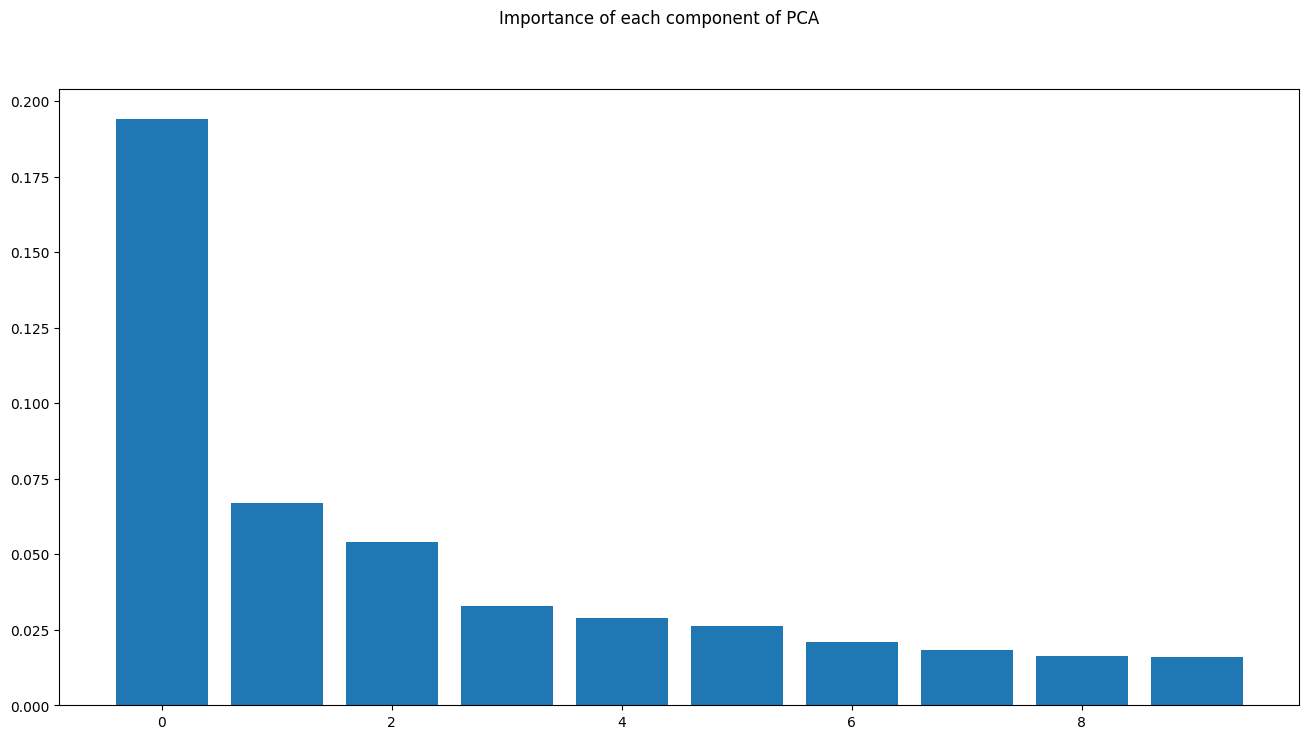

In [37]:
plt.figure(figsize=(16, 8))
plt.suptitle('Importance of each component of PCA')
plt.bar(range(len(pca.explained_variance_ratio_)), pca.explained_variance_ratio_)

X.shape: (1524, 23616) ; X_train_pca.shape: (975, 10)


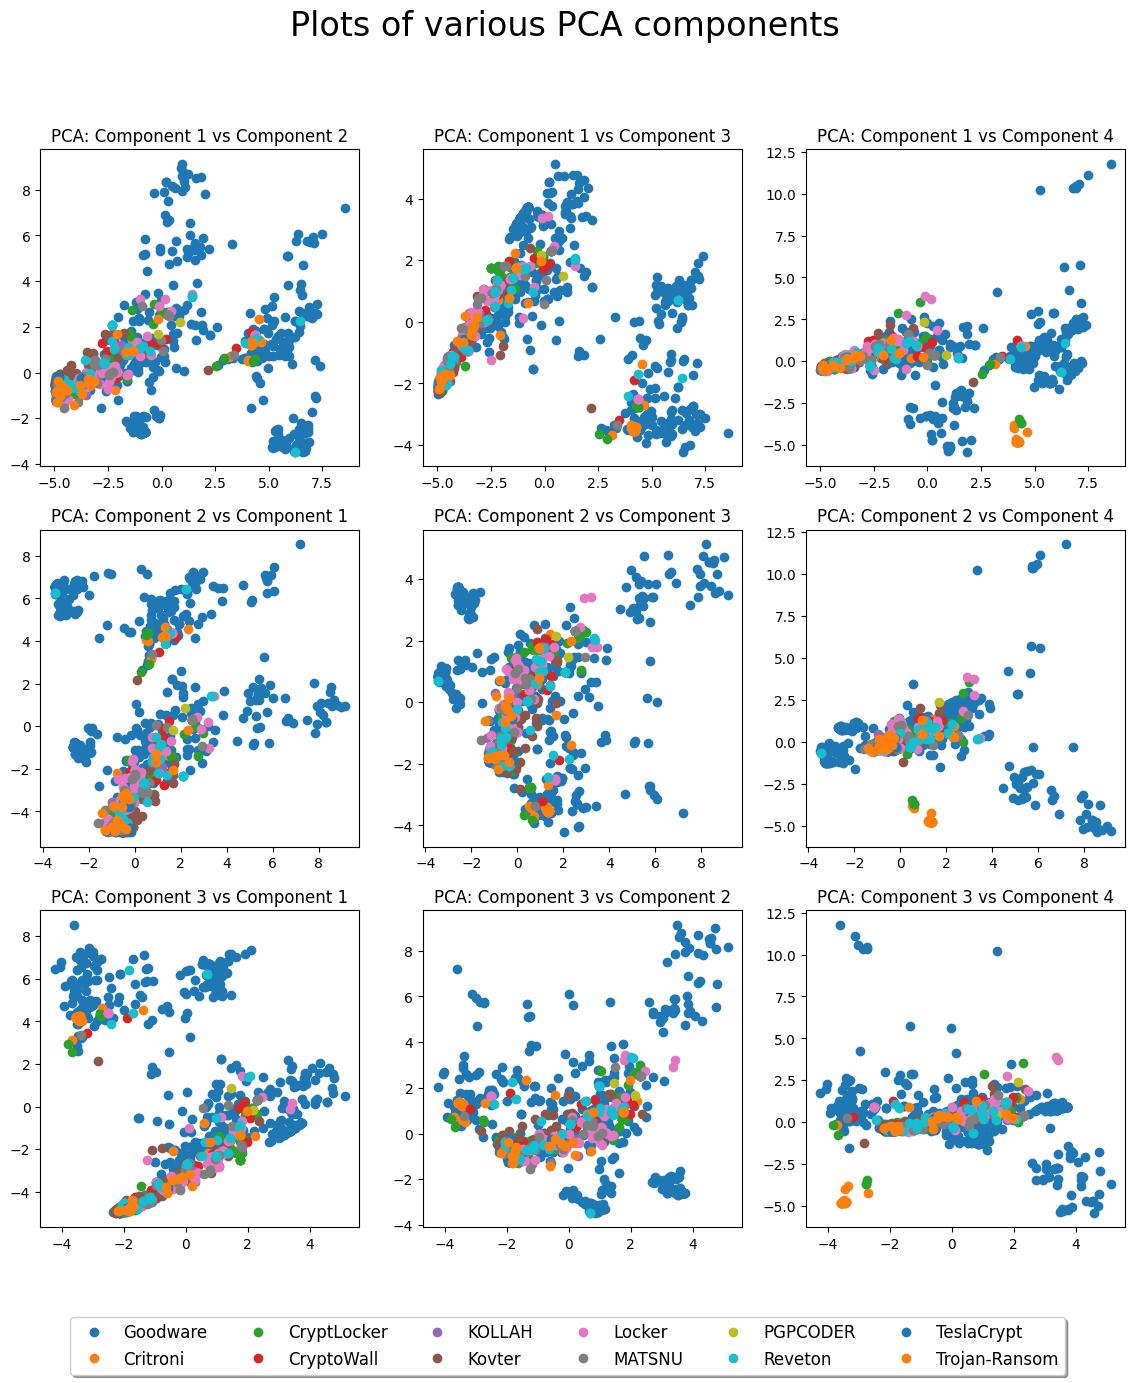

In [38]:
X_train_pca = pca.transform(X_train)
print('X.shape:', X.shape, '; X_train_pca.shape:', X_train_pca.shape)
fig, axes = plt.subplots(3, 3)
fig.set_size_inches(14, 14)
fig.suptitle('Plots of various PCA components', fontsize=24)

for class_idx in class_labels:
    indices = (y_train == class_idx)
    i2 = 0
    for i in range(3):
        j2 = 0
        for j in range(4):
            if i == j: continue
            x_coords = X_train_pca[indices, i]
            y_coords = X_train_pca[indices, j]
            class_name = class_names[class_idx]
            axes[i2, j2].plot(x_coords, y_coords, 'o', label=class_name)
            subplot_title = f'PCA: Component {i + 1} vs Component {j + 1}'
            axes[i2, j2].set_title(subplot_title)
            j2 += 1
        i2 += 1

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(handles=handles, labels=labels, loc='lower center', ncol=6, fancybox=True, shadow=True, fontsize=12)


### MLP without PCA

In [39]:
mlp = MLPClassifier(hidden_layer_sizes=(128, 128, 128, len(class_names)), max_iter=10, random_state=105, verbose=True)
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)
y_prob = mlp.predict_proba(X_test)
mlp_metrics_multi = calculate_metrics(y_test, y_pred, y_prob, class_names)
mlp_metrics_multi['label-type'] = 'multi'
mlp_metrics_multi['model'] = 'MLP-without-PCA'
mlp_metrics_multi = mlp_metrics_multi.sort_values(by='class_label', ignore_index=True)
mlp_metrics_multi

Iteration 1, loss = 2.17181521
Iteration 2, loss = 1.70453654
Iteration 3, loss = 1.43796568
Iteration 4, loss = 1.28460799
Iteration 5, loss = 1.15954006
Iteration 6, loss = 1.07924585
Iteration 7, loss = 1.01218227
Iteration 8, loss = 0.94160244
Iteration 9, loss = 0.87118260
Iteration 10, loss = 0.79931621


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


      class_label  accuracy  precision    recall  f1_score  area_under_roc  \
0        Goodware  0.950820   0.926471  1.000000  0.961832        0.985860   
1        Critroni  0.980328   0.833333  0.500000  0.625000        0.928136   
2     CryptLocker  0.931148   0.000000  0.000000       NaN        0.926392   
3      CryptoWall  0.970492   0.000000  0.000000       NaN        0.785285   
4          KOLLAH  0.983607   0.000000  0.000000       NaN        0.806000   
5          Kovter  0.970492   1.000000  0.307692  0.470588        0.953372   
6          Locker  0.852459   0.217391  0.526316  0.307692        0.852319   
7          MATSNU  0.895082   0.222222  0.666667  0.333333        0.934585   
8        PGPCODER  0.996721   0.000000  0.000000       NaN        0.529605   
9         Reveton  0.970492   1.000000  0.500000  0.666667        0.907859   
10     TeslaCrypt  0.996721   0.000000  0.000000       NaN        0.845395   
11  Trojan-Ransom  0.977049   0.000000  0.000000       NaN      

/tmp/ipython-input-575389311.py:35: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * recall * precision / (recall + precision)
/tmp/ipython-input-575389311.py:35: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * recall * precision / (recall + precision)
/tmp/ipython-input-575389311.py:35: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * recall * precision / (recall + precision)
/tmp/ipython-input-575389311.py:35: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * recall * precision / (recall + precision)
/tmp/ipython-input-575389311.py:35: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * recall * precision / (recall + precision)
/tmp/ipython-input-575389311.py:35: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * recall * precision / (recall + precision)


,class_label,accuracy,precision,recall,f1_score,area_under_roc,area_under_pr,label-type,model
0,Critroni,0.980328,0.833333,0.500000,0.625000,0.928136,0.679559,multi,MLP-without-PCA
1,CryptLocker,0.931148,0.000000,0.000000,NaN,0.926392,0.516281,multi,MLP-without-PCA
2,CryptoWall,0.970492,0.000000,0.000000,NaN,0.785285,0.068486,multi,MLP-without-PCA
3,Goodware,0.950820,0.926471,1.000000,0.961832,0.985860,0.990492,multi,MLP-without-PCA
4,KOLLAH,0.983607,0.000000,0.000000,NaN,0.806000,0.048717,multi,MLP-without-PCA
5,Kovter,0.970492,1.000000,0.307692,0.470588,0.953372,0.637632,multi,MLP-without-PCA
6,Locker,0.852459,0.217391,0.526316,0.307692,0.852319,0.407276,multi,MLP-without-PCA
7,MATSNU,0.895082,0.222222,0.666667,0.333333,0.934585,0.570699,multi,MLP-without-PCA
8,PGPCODER,0.996721,0.000000,0.000000,NaN,0.529605,0.003472,multi,MLP-without-PCA
9,Reveton,0.970492,1.000000,0.500000,0.666667,0.907859,0.670459,multi,MLP-without-PCA


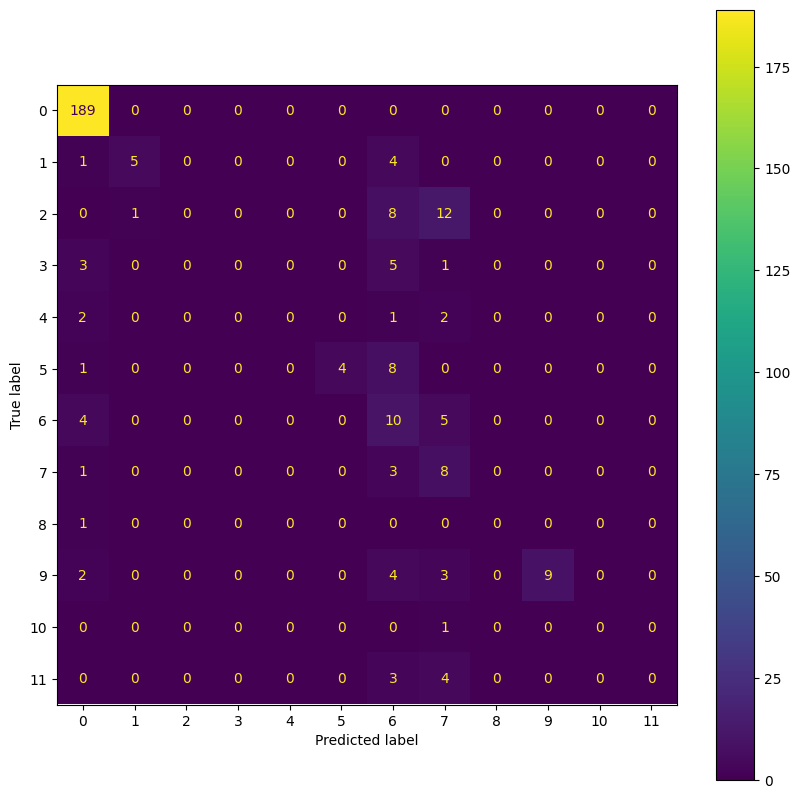

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)

### MLP with PCA

In [41]:
n_components = 100
pca = PCA(n_components=n_components)
pca.fit(X_train)
print(f'Variance explained by first {n_components} components:', sum(pca.explained_variance_ratio_))

# transform train dataset using PCA
X_train_pca = pca.transform(X_train)
print('X_train.shape:', X_train.shape, '; X_train_pca.shape:', X_train_pca.shape)
# transform val dataset using PCA
X_val_pca = pca.transform(X_val)
print('X_val.shape:', X_val.shape, '; X_val_pca.shape:', X_val_pca.shape)
# transform test dataset using PCA
X_test_pca = pca.transform(X_test)
print('X_test.shape:', X_test.shape, '; X_test_pca.shape:', X_test_pca.shape)


Variance explained by first 100 components: 0.8265052563253716
X_train.shape: (975, 23616) ; X_train_pca.shape: (975, 100)
X_val.shape: (244, 23616) ; X_val_pca.shape: (244, 100)
X_test.shape: (305, 23616) ; X_test_pca.shape: (305, 100)


In [42]:
mlp = MLPClassifier(hidden_layer_sizes=(128, 128, 128, len(class_names)), max_iter=10, random_state=105, verbose=True)
mlp.fit(X_train_pca, y_train)
y_pred = mlp.predict(X_test_pca)
y_prob = mlp.predict_proba(X_test_pca)
mlp_pca_metrics_multi = calculate_metrics(y_test, y_pred, y_prob, labels)
mlp_pca_metrics_multi['label-type'] = 'multi'
mlp_pca_metrics_multi['model'] = 'MLP-with-PCA'
mlp_pca_metrics_multi = mlp_pca_metrics_multi.sort_values(by='class_label', ignore_index=True)
mlp_pca_metrics_multi

Iteration 1, loss = 2.10156544
Iteration 2, loss = 1.63320043
Iteration 3, loss = 1.43700871
Iteration 4, loss = 1.27422099
Iteration 5, loss = 1.15593982
Iteration 6, loss = 1.07203095
Iteration 7, loss = 0.99567209
Iteration 8, loss = 0.93414778
Iteration 9, loss = 0.87748686
Iteration 10, loss = 0.82625584
      class_label  accuracy  precision    recall  f1_score  area_under_roc  \
0        Goodware  0.944262   0.917476  1.000000  0.956962        0.994663   
1        Critroni  0.983607   0.857143  0.600000  0.705882        0.950339   
2     CryptLocker  0.904918   0.214286  0.142857  0.171429        0.888414   
3      CryptoWall  0.970492   0.000000  0.000000       NaN        0.853604   
4          KOLLAH  0.983607   0.000000  0.000000       NaN        0.740000   
5          Kovter  0.957377   0.000000  0.000000       NaN        0.930717   
6          Locker  0.806557   0.187500  0.631579  0.289157        0.889584   
7          MATSNU  0.963934   0.666667  0.166667  0.266667       

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/tmp/ipython-input-575389311.py:35: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * recall * precision / (recall + precision)
/tmp/ipython-input-575389311.py:35: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * recall * precision / (recall + precision)
/tmp/ipython-input-575389311.py:35: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * recall * precision / (recall + precision)
/tmp/ipython-input-575389311.py:35: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * recall * precision / (recall + precision)
/tmp/ipython-input-575389311.py:35: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * recall * precision / (recall + precision)
/t

,class_label,accuracy,precision,recall,f1_score,area_under_roc,area_under_pr,label-type,model
0,Critroni,0.983607,0.857143,0.600000,0.705882,0.950339,0.705754,multi,MLP-with-PCA
1,CryptLocker,0.904918,0.214286,0.142857,0.171429,0.888414,0.260272,multi,MLP-with-PCA
2,CryptoWall,0.970492,0.000000,0.000000,NaN,0.853604,0.214743,multi,MLP-with-PCA
3,Goodware,0.944262,0.917476,1.000000,0.956962,0.994663,0.996545,multi,MLP-with-PCA
4,KOLLAH,0.983607,0.000000,0.000000,NaN,0.740000,0.028095,multi,MLP-with-PCA
5,Kovter,0.957377,0.000000,0.000000,NaN,0.930717,0.588586,multi,MLP-with-PCA
6,Locker,0.806557,0.187500,0.631579,0.289157,0.889584,0.373289,multi,MLP-with-PCA
7,MATSNU,0.963934,0.666667,0.166667,0.266667,0.890643,0.415440,multi,MLP-with-PCA
8,PGPCODER,0.996721,0.000000,0.000000,NaN,0.832237,0.009615,multi,MLP-with-PCA
9,Reveton,0.970492,0.909091,0.555556,0.689655,0.912892,0.706066,multi,MLP-with-PCA


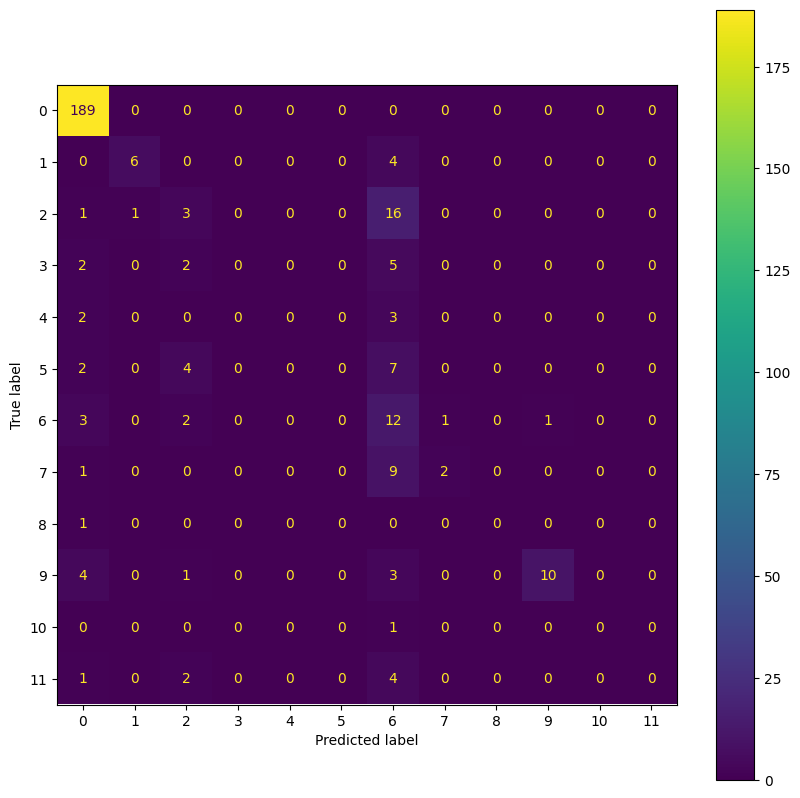

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)

In [44]:
pd.concat([mlp_metrics_multi, mlp_pca_metrics_multi], axis=0)

,class_label,accuracy,precision,recall,f1_score,area_under_roc,area_under_pr,label-type,model
0,Critroni,0.980328,0.833333,0.500000,0.625000,0.928136,0.679559,multi,MLP-without-PCA
1,CryptLocker,0.931148,0.000000,0.000000,NaN,0.926392,0.516281,multi,MLP-without-PCA
2,CryptoWall,0.970492,0.000000,0.000000,NaN,0.785285,0.068486,multi,MLP-without-PCA
3,Goodware,0.950820,0.926471,1.000000,0.961832,0.985860,0.990492,multi,MLP-without-PCA
4,KOLLAH,0.983607,0.000000,0.000000,NaN,0.806000,0.048717,multi,MLP-without-PCA
5,Kovter,0.970492,1.000000,0.307692,0.470588,0.953372,0.637632,multi,MLP-without-PCA
6,Locker,0.852459,0.217391,0.526316,0.307692,0.852319,0.407276,multi,MLP-without-PCA
7,MATSNU,0.895082,0.222222,0.666667,0.333333,0.934585,0.570699,multi,MLP-without-PCA
8,PGPCODER,0.996721,0.000000,0.000000,NaN,0.529605,0.003472,multi,MLP-without-PCA
9,Reveton,0.970492,1.000000,0.500000,0.666667,0.907859,0.670459,multi,MLP-without-PCA


---